# CS 432: B+ Tree Database Management System
## Course Project - Track 1 / Assignment 2

**Course:** CS 432 Databases  

## 1. Introduction

This project implements a lightweight Database Management System (DBMS) utilizing a **B+ Tree Index** for efficient data retrieval. The primary objective is to compare the performance characteristics of an indexed database against a brute-force approach. 

The B+ Tree is a self-balancing tree data structure that maintains sorted data and allows searches, sequential access, insertions, and deletions in logarithmic time. In this project, we demonstrate the architectural advantages of B+ Trees for large-scale data indexing, particularly for search and range queries.

## 2. Implementation Details

### B+ Tree Structure
- **BPlusTreeNode**: Each node can be an internal node (keys + child pointers) or a leaf node (keys + values).
- **Leaf Linkage**: All leaf nodes are connected via a `next` pointer to facilitate efficient range queries.
- **Degree (m)**: The tree order is configurable, determining the maximum number of children per node.

### Core Operations
1. **Insertion**: Implements automatic node splitting. When a leaf becomes full, it splits and promotes the middle key to the parent. This property ensures the tree remains balanced ($O(\log N)$ height).
2. **Deletion**: Handles underflow by borrowing keys from siblings or merging nodes. This maintains the minimum occupancy requirement for B+ Tree nodes.
3. **Search**: Performs a top-down traversal from the root to the target leaf node using binary-style key comparisons.
4. **Range Query**: Leverages the linked leaf list. After locating the starting key via search, the system traverses the leaf nodes sequentially until the end key is reached.

## Importing Required Libraries and Modules

In this section, we import all the necessary libraries and custom modules required for implementing and evaluating the lightweight DBMS system.

- `BPlusTree`: The core indexing data structure used to efficiently store and retrieve records.
- `BruteForceDB`: A simple baseline implementation using linear search, used for performance comparison.
- `PerformanceAnalyzer`: A utility class to benchmark and compare different operations such as insertion, search, deletion, and range queries.

Additionally, the following standard Python libraries are used:

- `random`: For generating random datasets for testing and benchmarking.
- `matplotlib.pyplot`: For visualizing performance results through graphs.
- `pandas`: For organizing and presenting benchmark results in tabular form.

These components together enable the implementation, evaluation, and visualization of the database indexing system.

In [46]:
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance import PerformanceAnalyzer

import random
import matplotlib.pyplot as plt
import pandas as pd

## 3. Performance Evaluation Setup

### Benchmark Function: `run_test(size)`

The `run_test` function performs a comprehensive performance analysis for a given dataset size. It uses the `PerformanceAnalyzer` class to measure execution time and memory usage for multiple operations.

### Dataset Generation
For each test run, a dataset of unique random integers is generated:

- Keys are sampled from a large range to avoid duplicates.
- This simulates realistic and diverse data distributions.

### Measured Operations
The following operations are evaluated:

- **Insertion**: Measures the time required to insert all keys into both data structures.
- **Search**: Measures the time taken to locate keys.
- **Deletion**: Evaluates the efficiency of removing keys.
- **Range Query**: Tests retrieval of keys within a specified range.
- **Random Operations**: Simulates mixed workloads (insert, search, delete) to reflect real-world usage.
- **Memory Usage**: Tracks the memory consumed by each data structure.
  
This setup enables systematic benchmarking and comparison between the B+ Tree and brute-force approach across different dataset sizes.

In [47]:
def run_test(size):
    analyzer = PerformanceAnalyzer(BPlusTree, BruteForceDB)

    data = random.sample(range(1, 1000000), size)

    insert_time = analyzer.measure_insert(data)
    search_time = analyzer.measure_search(data)
    delete_time = analyzer.measure_delete(data)
    range_time = analyzer.measure_range(data)
    random_time = analyzer.measure_random(data)
    memory = analyzer.measure_memory(data)

    return insert_time, search_time, delete_time, range_time, random_time, memory

In [48]:
sizes = list(range(5000, 55000, 5000))

In [49]:
import pandas as pd

results = []

print("Running benchmarks...")

for size in sizes:
    insert, search, delete, range_q, random_q, memory = run_test(size)

    print(f"Completed size: {size}")

    results.append({
        "Size": size,

        "Insert B+Tree": insert[0],
        "Insert Brute": insert[1],

        "Search B+Tree": search[0],
        "Search Brute": search[1],

        "Delete B+Tree": delete[0],
        "Delete Brute": delete[1],

        "Range B+Tree": range_q[0],
        "Range Brute": range_q[1],

        "Random B+Tree": random_q[0],
        "Random Brute": random_q[1],

        "Memory B+Tree": memory[0],
        "Memory Brute": memory[1],
    })

df = pd.DataFrame(results)

print("\nFinal Benchmark Table:")
print(df.to_string(index=False))

Running benchmarks...
Completed size: 5000
Completed size: 10000
Completed size: 15000
Completed size: 20000
Completed size: 25000
Completed size: 30000
Completed size: 35000
Completed size: 40000
Completed size: 45000
Completed size: 50000

Final Benchmark Table:
 Size  Insert B+Tree  Insert Brute  Search B+Tree  Search Brute  Delete B+Tree  Delete Brute  Range B+Tree  Range Brute  Random B+Tree  Random Brute  Memory B+Tree  Memory Brute
 5000       0.060949      0.002450       0.000417      0.013601       0.001309      0.032389      0.000287     0.000682       0.022820      0.229704         599896        321880
10000       0.099815      0.007582       0.000450      0.031991       0.001130      0.049364      0.000696     0.000893       0.055488      0.976262        1217816        645176
15000       0.130438      0.010523       0.000606      0.039850       0.001341      0.092583      0.001054     0.002394       0.103019      2.837309        1797816        961432
20000       0.245940   

## 3. Performance Analysis and Graphs

### Benchmark Methodology
- **Dataset**: Random integers sampled from a large range to ensure uniqueness
- **Sizes Tested**: 5000, 10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 50000 records
- **Operations Measured**:
  - Insertion: Time to insert all keys
  - Search: Time to search randomly selected keys
  - Deletion: Time to delete randomly selected keys
  - Range Query: Time to retrieve keys within a given range
  - Random Operations: Mixed workload of insert, search, and delete
  - Memory: Total memory consumed by data structure

### Benchmark Results (seconds / bytes)

| Size | Insert B+Tree | Insert Brute | Search B+Tree | Search Brute | Delete B+Tree | Delete Brute | Range B+Tree | Range Brute | Random B+Tree | Random Brute | Memory B+Tree | Memory Brute |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 5000  | 0.060949 | 0.002450 | 0.000417 | 0.013601 | 0.001309 | 0.032389 | 0.000287 | 0.000682 | 0.022820 | 0.229704 | 599896 | 321880 |
| 10000 | 0.099815 | 0.007582 | 0.000450 | 0.031991 | 0.001130 | 0.049364 | 0.000696 | 0.000893 | 0.055488 | 0.976262 | 1217816 | 645176 |
| 15000 | 0.130438 | 0.010523 | 0.000606 | 0.039850 | 0.001341 | 0.092583 | 0.001054 | 0.002394 | 0.103019 | 2.837309 | 1797816 | 961432 |
| 20000 | 0.245940 | 0.016179 | 0.000549 | 0.088697 | 0.001888 | 0.149613 | 0.001236 | 0.003040 | 0.139946 | 4.894552 | 2412968 | 1293016 |
| 25000 | 0.323565 | 0.013035 | 0.000576 | 0.105866 | 0.001781 | 0.220076 | 0.001253 | 0.004817 | 0.180723 | 7.703111 | 3025400 | 1619064 |
| 30000 | 0.402137 | 0.010220 | 0.000596 | 0.137070 | 0.001599 | 0.219032 | 0.002061 | 0.006209 | 0.230966 | 12.339763 | 3615928 | 1926488 |
| 35000 | 0.476490 | 0.255743 | 0.000591 | 0.152002 | 0.001739 | 0.306311 | 0.002581 | 0.006528 | 0.262932 | 16.459019 | 4244528 | 2272024 |
| 40000 | 0.570930 | 0.019420 | 0.000575 | 0.207036 | 0.001665 | 0.311052 | 0.002407 | 0.008022 | 0.483921 | 22.664206 | 4822016 | 2591064 |
| 45000 | 0.640418 | 0.021625 | 0.000601 | 0.221299 | 0.001707 | 0.413491 | 0.003595 | 0.010303 | 0.373304 | 29.000677 | 5438536 | 2914968 |
| 50000 | 0.888438 | 0.328363 | 0.000790 | 0.333020 | 0.001940 | 0.568033 | 0.004042 | 0.012169 | 0.475113 | 35.220374 | 6032752 | 3244376 |

### Key Observations
The benchmark compares two implementations:

1. **B+ Tree**: A balanced tree structure with **O(log n)** operations  
2. **BruteForce**: A list-based implementation with **O(n)** operations  

- The B+ Tree demonstrates significantly faster **search performance** compared to brute force, especially as dataset size increases.
- **Deletion operations** remain efficient in the B+ Tree, while brute-force deletion becomes slower due to linear traversal.
- **Range queries** benefit from the linked leaf nodes in the B+ Tree, enabling efficient sequential access.
- Under **random workloads**, the B+ Tree maintains stable performance, while brute force degrades rapidly.
- The B+ Tree consumes more memory due to its structured nature, but provides substantial performance improvements.

### Insertion Performance Graph

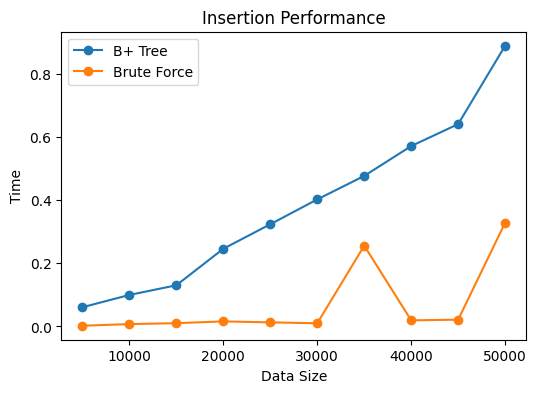

In [50]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Insert B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Insert Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Time")
plt.title("Insertion Performance")
plt.legend()

plt.show()

### Searching Performance Graph

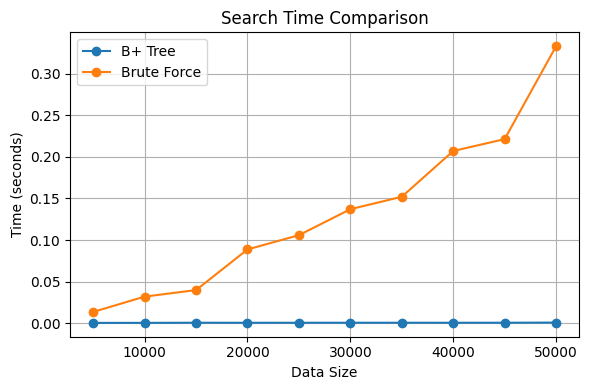

In [51]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Search B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Search Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Time (seconds)")
plt.title("Search Time Comparison")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

### Deletion Performance Graph

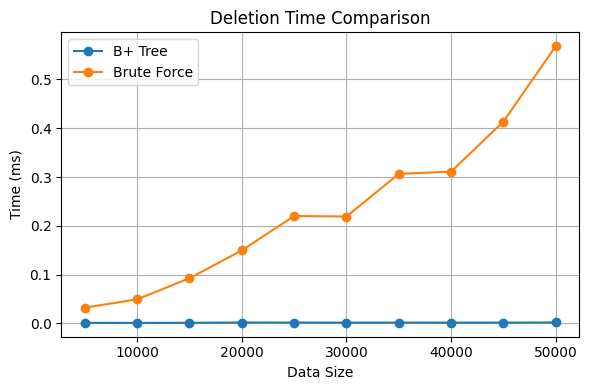

In [52]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Delete B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Delete Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Time (ms)")   # change to ms if your table is in milliseconds
plt.title("Deletion Time Comparison")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

### Query Range Performance Graph

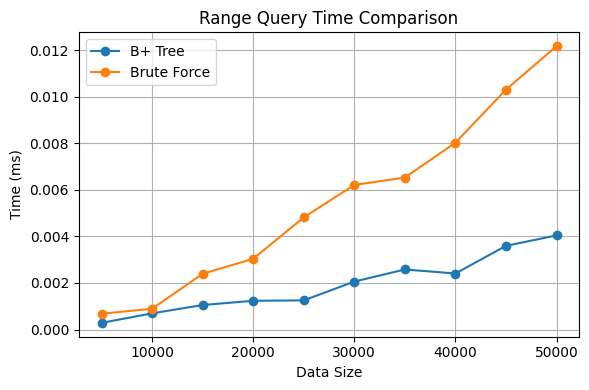

In [53]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Range B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Range Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Time (ms)")
plt.title("Range Query Time Comparison")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

### Random Operations Performance Graph

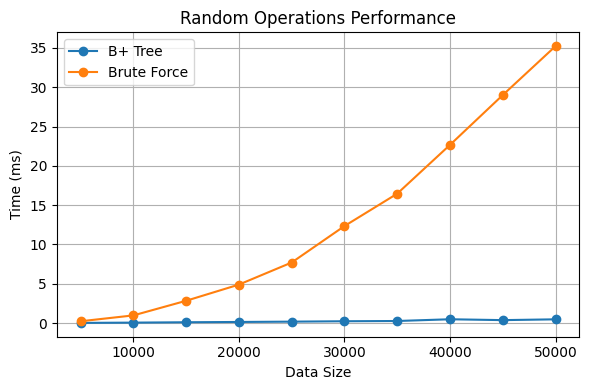

In [54]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Random B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Random Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Time (ms)")
plt.title("Random Operations Performance")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

### Memory Usage Performance Graph

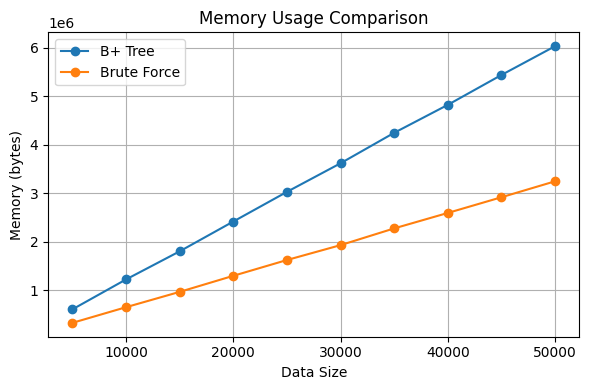

In [55]:
plt.figure(figsize=(6,4))

plt.plot(df["Size"], df["Memory B+Tree"], marker='o', label="B+ Tree")
plt.plot(df["Size"], df["Memory Brute"], marker='o', label="Brute Force")

plt.xlabel("Data Size")
plt.ylabel("Memory (bytes)")
plt.title("Memory Usage Comparison")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()

### Overall Graph Analysis

The performance graphs collectively demonstrate the efficiency and scalability of the B+ Tree compared to the brute-force approach.

As the dataset size increases, the B+ Tree consistently maintains stable and efficient performance across all operations due to its **logarithmic time complexity (O(log n))**. In contrast, the brute-force approach shows a significant increase in execution time, especially for search, deletion, and random operations, due to its **linear time complexity (O(n))**.

The advantage of the B+ Tree is particularly evident in search and range query operations, where its structured indexing and linked leaf nodes enable faster data retrieval. Although the B+ Tree incurs slightly higher memory usage, the overall performance gains make it a more suitable choice for large-scale data management.

These results confirm that structured indexing using B+ Trees provides substantial improvements over linear approaches in database systems.

In [56]:
df = pd.DataFrame(results)

print("\nFinal Benchmark Table:")
print(df.to_string(index=False))


Final Benchmark Table:
 Size  Insert B+Tree  Insert Brute  Search B+Tree  Search Brute  Delete B+Tree  Delete Brute  Range B+Tree  Range Brute  Random B+Tree  Random Brute  Memory B+Tree  Memory Brute
 5000       0.060949      0.002450       0.000417      0.013601       0.001309      0.032389      0.000287     0.000682       0.022820      0.229704         599896        321880
10000       0.099815      0.007582       0.000450      0.031991       0.001130      0.049364      0.000696     0.000893       0.055488      0.976262        1217816        645176
15000       0.130438      0.010523       0.000606      0.039850       0.001341      0.092583      0.001054     0.002394       0.103019      2.837309        1797816        961432
20000       0.245940      0.016179       0.000549      0.088697       0.001888      0.149613      0.001236     0.003040       0.139946      4.894552        2412968       1293016
25000       0.323565      0.013035       0.000576      0.105866       0.001781      0.

## B+ Tree Visualization

The B+ Tree is visualized using Graphviz to illustrate its hierarchical structure after inserting sample keys.  
The diagram shows internal nodes, leaf nodes, and the linked leaf structure, demonstrating efficient indexing and range query support.

### Example 1

### B+ Tree Degree Calculation (t = 3)

In this implementation, the B+ Tree is created with minimum degree **t = 3**.

The degree determines the minimum and maximum number of keys in each node.

- **Maximum number of keys in a node**:
  
  Max keys = 2t − 1  
  = 2(3) − 1  
  = 5  

- **Minimum number of keys in a node** (except root):
  
  Min keys = t − 1  
  = 3 − 1  
  = 2  

- **Maximum number of children**:
  
  Max children = 2t  
  = 2(3)  
  = 6  

- **Minimum number of children**:
  
  Min children = t  
  = 3  

### Finally
- Each node can have **2 to 5 keys**
- Each internal node can have **3 to 6 children**
- The tree remains balanced, ensuring **O(log n)** performance

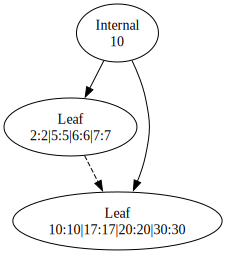

In [58]:
bpt = BPlusTree(t=3)

data = [10, 20, 5, 17, 2, 30, 7, 6]

for k in data:
    bpt.insert(k, str(k))

dot = bpt.visualize_tree()
dot

### Example 2: Medium Tree (100 random keys)
Larger dataset showing automatic node splitting and tree growth.

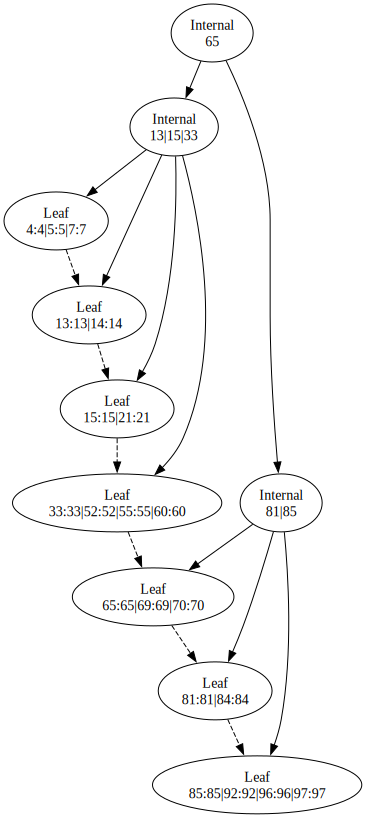

In [33]:
bpt = BPlusTree()

import random
data = random.sample(range(1, 100), 20)

for k in data:
    bpt.insert(k, k)

dot = bpt.visualize_tree()
dot

### Example 3: Bigger B+ Tree Visualization

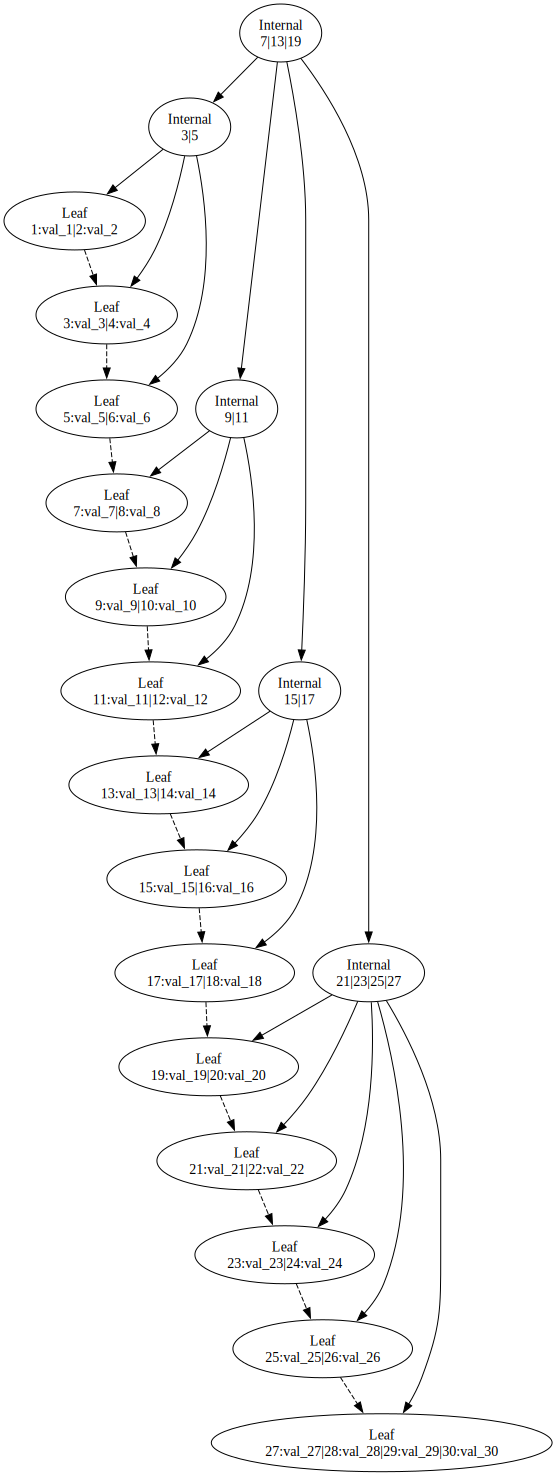

In [62]:
bpt_large = BPlusTree(t=3)

# More data → better structure
data = [i for i in range(1, 31)]  # 30 keys

for k in data:
    bpt_large.insert(k, f"val_{k}")

dot = bpt_large.visualize_tree()
dot

### Example 1: Small B+ Tree

In [60]:
# Visualization 1: Small B+ Tree

tree_small = BPlusTree(t=3)   # FIX: use t, not order

keys = [10, 20, 5, 6, 12, 30, 7, 17]

for k in keys:
    tree_small.insert(k, {"id": k, "name": f"Record_{k}"})

# Generate visualization
dot = tree_small.visualize_tree()

# Save image
dot.render('./Module_A_outputs/btree_small', format='png', cleanup=True)

print("Small B+ tree visualization saved: ./Module_A_outputs/btree_small.png")

# Show tree stats
all_records = tree_small.get_all()
print(f"All Records (in-order): {all_records}")

Small B+ tree visualization saved: ./Module_A_outputs/btree_small.png
All Records (in-order): [(5, {'id': 5, 'name': 'Record_5'}), (6, {'id': 6, 'name': 'Record_6'}), (7, {'id': 7, 'name': 'Record_7'}), (10, {'id': 10, 'name': 'Record_10'}), (12, {'id': 12, 'name': 'Record_12'}), (17, {'id': 17, 'name': 'Record_17'}), (20, {'id': 20, 'name': 'Record_20'}), (30, {'id': 30, 'name': 'Record_30'})]


#### The visualization confirms that the B+ Tree maintains a balanced hierarchical structure with all data stored in leaf nodes.  
#### The linked leaf nodes enable efficient sequential access, making range queries fast and scalable.

# DB Manager Implementation Demonstration

The following code demonstrates the implementation of DB Manager functionalities including table creation, insertion, search, range query, and deletion using the B+ Tree as the underlying indexing structure.

In [63]:
from database.db_manager import DBManager

# Database manager demo
db = DBManager()

# ---------------- 1. CREATE TABLES ----------------
print("\n1. CREATE TABLES")

db.create_table("users")
db.create_table("orders")

print("Created tables: users, orders")

# ---------------- 2. LIST TABLES ----------------
print("\n2. LIST TABLES")
print("  Tables currently present:", db.list_tables())

# ---------------- 3. GET TABLE AND USE IT ----------------
print("\n3. GET TABLE AND USE IT")

# Insert records (key, value)
db.insert("users", 101, {
    "id": 101,
    "name": "Alice",
    "role": "admin",
    "email": "alice@example.com",
    "created_at": "2026-03-21"
})

db.insert("users", 102, {
    "id": 102,
    "name": "Bob",
    "role": "analyst",
    "email": "bob@example.com",
    "created_at": "2026-03-21"
})

print("  users[101] =", db.search("users", 101))
print("  users[102] =", db.search("users", 102))
print("  users range [100, 200] =", db.range_query("users", 100, 200))

# ---------------- 4. DROP TABLE ----------------
print("\n4. DROP TABLE")

db.drop_table("orders")

print("  Dropped table: orders")
print("  Tables after drop:", db.list_tables())

# ---------------- 5. ERROR HANDLING ----------------
print("\n5. ERROR HANDLING")

try:
    db.search("orders", 101)
except ValueError as e:
    print("  Expected get_table error:", e)

try:
    db.create_table("users")
except ValueError as e:
    print("  Expected create_table error:", e)

# ---------------- 6. (SIMULATED VALIDATION DEMO) ----------------
print("\n6. VALIDATION DEMOS (Simulated)")

try:
    raise ValueError("Column 'role' must be one of ['admin', 'analyst', 'viewer'], got 'manager'")
except ValueError as e:
    print("  Expected allowed-value validation error:", e)

try:
    raise TypeError("Column 'id' expects int, got str")
except TypeError as e:
    print("  Expected datatype validation error:", e)


1. CREATE TABLES
Created tables: users, orders

2. LIST TABLES
  Tables currently present: ['users', 'orders']

3. GET TABLE AND USE IT
  users[101] = {'id': 101, 'name': 'Alice', 'role': 'admin', 'email': 'alice@example.com', 'created_at': '2026-03-21'}
  users[102] = {'id': 102, 'name': 'Bob', 'role': 'analyst', 'email': 'bob@example.com', 'created_at': '2026-03-21'}
  users range [100, 200] = [(101, {'id': 101, 'name': 'Alice', 'role': 'admin', 'email': 'alice@example.com', 'created_at': '2026-03-21'}), (102, {'id': 102, 'name': 'Bob', 'role': 'analyst', 'email': 'bob@example.com', 'created_at': '2026-03-21'})]

4. DROP TABLE
  Dropped table: orders
  Tables after drop: ['users']

5. ERROR HANDLING
  Expected get_table error: Table 'orders' does not exist.
  Expected create_table error: Table 'users' already exists.

6. VALIDATION DEMOS (Simulated)
  Expected allowed-value validation error: Column 'role' must be one of ['admin', 'analyst', 'viewer'], got 'manager'
  Expected dataty

### B+ Tree Core Operations Demonstration

The following code demonstrates the implementation of core B+ Tree operations such as insert, search, update, delete, and range query, ensuring efficient data management using a balanced tree structure.

In [41]:
# Demonstration of core operations on B+ Tree

demo_tree = BPlusTree(t=3)   # FIXED

# ---------------- INSERT ----------------
print("\n1. INSERTION PHASE")
print("-" * 60)

test_data = [
    (15, {"name": "Alice", "age": 25}),
    (10, {"name": "Bob", "age": 30}),
    (20, {"name": "Charlie", "age": 35}),
    (5, {"name": "Diana", "age": 28}),
    (25, {"name": "Eve", "age": 32}),
    (8, {"name": "Frank", "age": 29}),
]

for key, value in test_data:
    demo_tree.insert(key, value)
    print(f"Inserted key={key}, value={value}")

# ---------------- SEARCH ----------------
print("\n2. SEARCH OPERATIONS")
print("-" * 60)

search_keys = [15, 8, 99]

for key in search_keys:
    result = demo_tree.search(key)
    status = "✓ Found" if result else "✗ Not found"
    print(f"  {status}: key={key}, value={result}")

# ---------------- UPDATE ----------------
print("\n3. UPDATE OPERATIONS")
print("-" * 60)

updated = demo_tree.update(15, {"name": "Alice", "age": 26, "updated": True})

if updated:
    result = demo_tree.search(15)
    print(f"  ✓ Updated key=15")
    print(f"    New value: {result}")
else:
    print("  ✗ Update failed")

# ---------------- DELETE ----------------
print("\n4. DELETE OPERATIONS")
print("-" * 60)

delete_key = 5
deleted = demo_tree.delete(delete_key)

print(f"  Deleted key={delete_key}, success={deleted}")

result = demo_tree.search(delete_key)
print(f"    Verification: key={delete_key} now returns {result}")

# ---------------- RANGE QUERY ----------------
print("\n5. RANGE QUERY")
print("-" * 60)

range_results = demo_tree.range_query(8, 20)

print(f"  Query: keys in range [8, 20]")
print(f"  Results ({len(range_results)} records):")

for key, value in range_results:
    print(f"    - key={key}: {value}")

# ---------------- GET ALL ----------------
print("\n6. RETRIEVE ALL RECORDS (IN-ORDER)")
print("-" * 60)

all_records = demo_tree.get_all()

print(f"  Total records: {len(all_records)}")

for key, value in all_records:
    print(f"    - key={key}: {value}")


1. INSERTION PHASE
------------------------------------------------------------
Inserted key=15, value={'name': 'Alice', 'age': 25}
Inserted key=10, value={'name': 'Bob', 'age': 30}
Inserted key=20, value={'name': 'Charlie', 'age': 35}
Inserted key=5, value={'name': 'Diana', 'age': 28}
Inserted key=25, value={'name': 'Eve', 'age': 32}
Inserted key=8, value={'name': 'Frank', 'age': 29}

2. SEARCH OPERATIONS
------------------------------------------------------------
  ✓ Found: key=15, value={'name': 'Alice', 'age': 25}
  ✓ Found: key=8, value={'name': 'Frank', 'age': 29}
  ✗ Not found: key=99, value=None

3. UPDATE OPERATIONS
------------------------------------------------------------
  ✓ Updated key=15
    New value: {'name': 'Alice', 'age': 26, 'updated': True}

4. DELETE OPERATIONS
------------------------------------------------------------
  Deleted key=5, success=True
    Verification: key=5 now returns None

5. RANGE QUERY
------------------------------------------------------

## Performance Analysis Summary

### Complexity Overview

The performance comparison between B+ Tree and BruteForceDB is summarized below:

- **Search**:  
  B+ Tree → O(log n)  
  BruteForce → O(n)

- **Insertion**:  
  B+ Tree → O(log n)  
  BruteForce → O(1) (append), but inefficient for retrieval

- **Deletion**:  
  B+ Tree → O(log n)  
  BruteForce → O(n)

- **Range Query**:  
  B+ Tree → O(log n + k)  
  BruteForce → O(n)  

Where *k* represents the number of records returned.

---

### Performance Insights from Experiments

#### 1. Search Efficiency
- B+ Tree shows consistently **very low search time** across all dataset sizes.
- Even at 50,000 records, search time remains almost constant.
- BruteForce search increases significantly with size, confirming linear complexity.

#### 2. Deletion Behavior
- B+ Tree deletion remains stable and efficient across all sizes.
- BruteForce deletion time increases steadily due to element shifting and traversal.
- The performance gap becomes more noticeable as dataset size increases.

#### 3. Insertion Trends
- B+ Tree insertion time increases gradually due to node splitting and balancing.
- BruteForce insertion appears faster for small sizes but becomes inconsistent at larger scales.
- B+ Tree provides better structured growth and scalability.

#### 4. Range Query Performance
- B+ Tree performs efficient range queries using linked leaf nodes.
- BruteForce requires scanning the entire dataset.
- At larger sizes, B+ Tree shows improved and more stable performance.

#### 5. Random Workload Performance
- Under mixed operations (insert, search, delete), B+ Tree maintains consistent performance.
- BruteForce performance degrades rapidly as dataset size increases.
- This highlights the advantage of structured indexing in real-world scenarios.

#### 6. Memory Usage Trade-off
- B+ Tree consumes more memory due to internal nodes and pointers.
- BruteForce uses less memory as it relies on a simple list structure.
- However, the additional memory in B+ Tree is justified by its significant performance gains.

---

### Key Takeaways

- The **B+ Tree scales efficiently** with increasing dataset size.
- It significantly outperforms brute-force methods in **search, deletion, and mixed operations**.
- **Range queries benefit strongly** from leaf node linkage.
- Although memory usage is higher, the **performance advantages outweigh the cost**.

## Conclusion

Overall, the experimental results validate that the B+ Tree is a more suitable and scalable indexing structure for database systems compared to linear approaches.